# Part 5: Design Decisions & Final Analysis

report purposes only!

## 5.1 Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, json
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = "/content/drive/MyDrive/svg-scaling"
PROJECT_DIR = "/content/drive/MyDrive/svg-scaling-laws"
sys.path.insert(0, PROJECT_DIR)

RESULTS_DIR = os.path.join(BASE_DIR, "results")
ANALYSIS_DIR = os.path.join(RESULTS_DIR, "analysis")
REPORT_DIR = os.path.join(BASE_DIR, "report_figures")
os.makedirs(REPORT_DIR, exist_ok=True)

Mounted at /content/drive


In [2]:
import importlib
from analysis import compare_sp_mup, extrapolation
importlib.reload(compare_sp_mup)
importlib.reload(extrapolation)

compare_sp_mup.compare_sp_vs_mup(RESULTS_DIR, ANALYSIS_DIR, mup_lr="1e-2")
extrapolation.extrapolate_scaling_law(RESULTS_DIR, ANALYSIS_DIR, mup_lr="1e-2")

Saved comparison plot to sp_vs_mup_scaling_lr1e-2.png

SP vs µP Comparison
Model         SP Loss    µP Loss          Δ    Improve
--------------------------------------------------
tiny           1.1600     1.0050    +0.1550     +13.4%
small          0.9988     0.9145    +0.0843      +8.4%
medium         0.8560     0.8511    +0.0049      +0.6%
large          0.7663     0.7853    -0.0190      -2.5%
xl             0.6799     0.7548    -0.0749     -11.0%

Scaling exponent (α):
  SP:  0.2206
  µP:  0.2360
  Improvement: +6.9%

Using µP (LR=1e-2) scaling law: L = 10.9713 · N^(-0.2360) + 0.6075
R² = 0.9950

Extrapolation Results:
  Largest trained model: 88,099,584 params → loss = 0.7548
  Extrapolation target:  880,995,840 params (10×)
  Predicted loss:        0.6925
  95% CI:                [0.6402, 0.7449]
  Uncertainty (σ):       0.0267
Saved extrapolation plot


{'parameterization': 'µP (LR=1e-2)',
 'fit': {'a': 10.971307784813728,
  'alpha': 0.23596890721880123,
  'c': 0.6075097321325099,
  'r_squared': 0.9949837178276112},
 'trained_models': {'tiny': {'params': 1311872, 'loss': 1.0049857759475709},
  'small': {'params': 3443136, 'loss': 0.9145311427116394},
  'medium': {'params': 12194688, 'loss': 0.8511341214179993},
  'large': {'params': 33565184, 'loss': 0.7853275668621064},
  'xl': {'params': 88099584, 'loss': 0.7548047161102295}},
 'extrapolation': {'target_params': 880995840,
  'factor': 10,
  'predicted_loss': 0.6925300437573858,
  'ci_95_low': 0.6401886540760771,
  'ci_95_high': 0.7448714334386946,
  'sigma': 0.026704790653728945}}

## 5.2 Model Architecture Summary Table

In [3]:
import yaml

with open(os.path.join(PROJECT_DIR, "configs", "model_configs.yaml")) as f:
    model_configs = yaml.safe_load(f)

# Load results
sp_path = os.path.join(RESULTS_DIR, "sp_scaling_summary.json")
if os.path.exists(sp_path):
    with open(sp_path) as f:
        sp_summary = json.load(f)

    print("| Model | Params | d_model | n_layers | n_heads | d_ff | Val Loss | Time (s) | Tok/s | GPU (GB) |")
    print("|-------|--------|---------|----------|---------|------|----------|----------|-------|----------|")
    for name in model_configs:
        cfg = model_configs[name]
        sp = sp_summary.get(name, {})
        print(f"| {name} | {sp.get('params', '?'):,} | {cfg['n_embd']} | {cfg['n_layer']} | "
              f"{cfg['n_head']} | {cfg['d_ff']} | {sp.get('final_val_loss', '?'):.4f} | "
              f"{sp.get('total_time_s', '?'):.0f} | {sp.get('tokens_per_sec', '?'):.0f} | "
              f"{sp.get('gpu_memory_gb', '?'):.2f} |")

| Model | Params | d_model | n_layers | n_heads | d_ff | Val Loss | Time (s) | Tok/s | GPU (GB) |
|-------|--------|---------|----------|---------|------|----------|----------|-------|----------|
| tiny | 1,311,872 | 128 | 4 | 4 | 512 | 1.1600 | 70 | 1751104 | 26.63 |
| small | 3,443,136 | 192 | 6 | 6 | 768 | 0.9988 | 112 | 1096438 | 26.63 |
| medium | 12,194,688 | 384 | 6 | 6 | 1536 | 0.8560 | 201 | 614248 | 26.63 |
| large | 33,565,184 | 512 | 10 | 8 | 2048 | 0.7663 | 365 | 337995 | 26.63 |
| xl | 88,099,584 | 768 | 12 | 12 | 3072 | 0.6799 | 744 | 165726 | 28.65 |


## 5.3 All Report Figures

Found 27 figures for the report:

example_00_len214.png


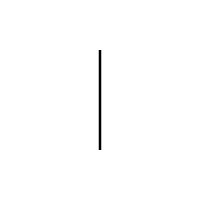


example_01_len739.png


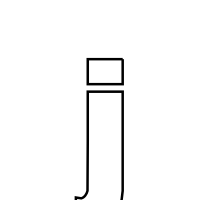


example_02_len925.png


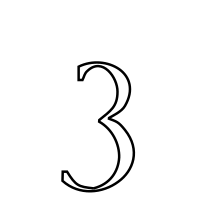


example_03_len1086.png


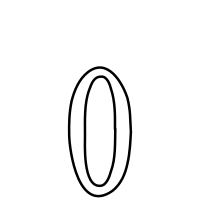


example_04_len1262.png


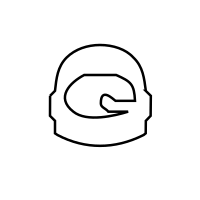


example_05_len1489.png


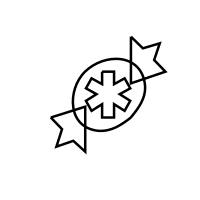


example_06_len1797.png


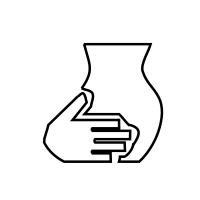


example_07_len2227.png


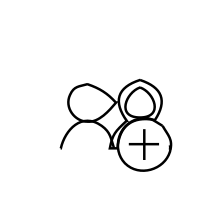


example_08_len2847.png


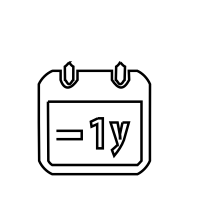


example_09_len3800.png


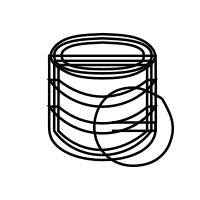


example_10_len5365.png


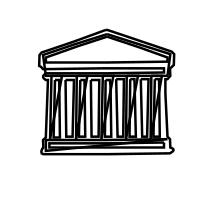


example_11_len9998.png


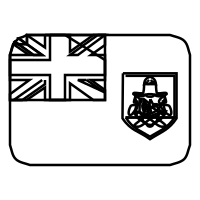


example_grid.png


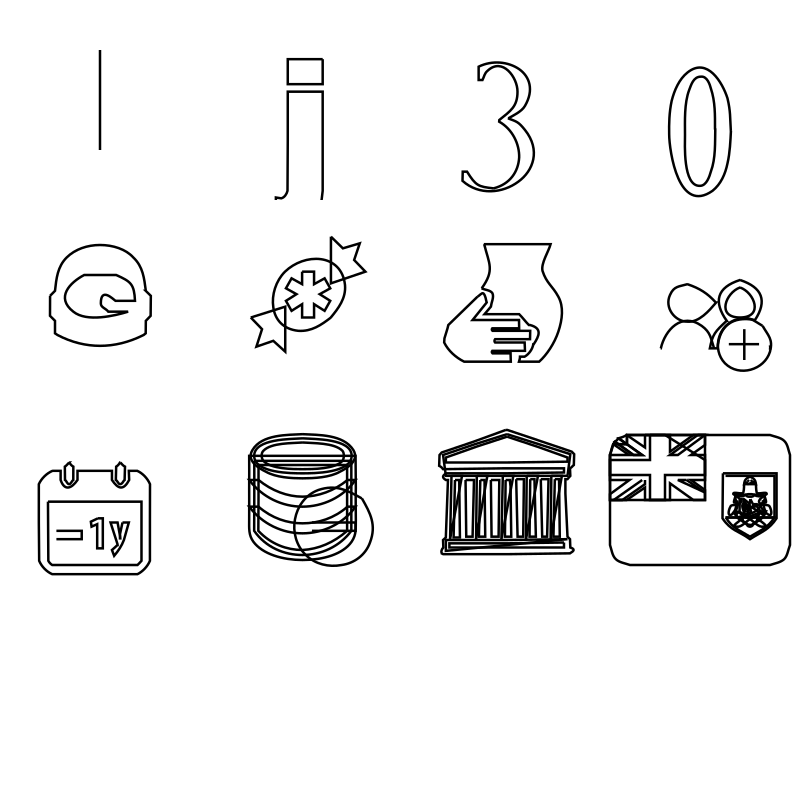


split_token_counts.png


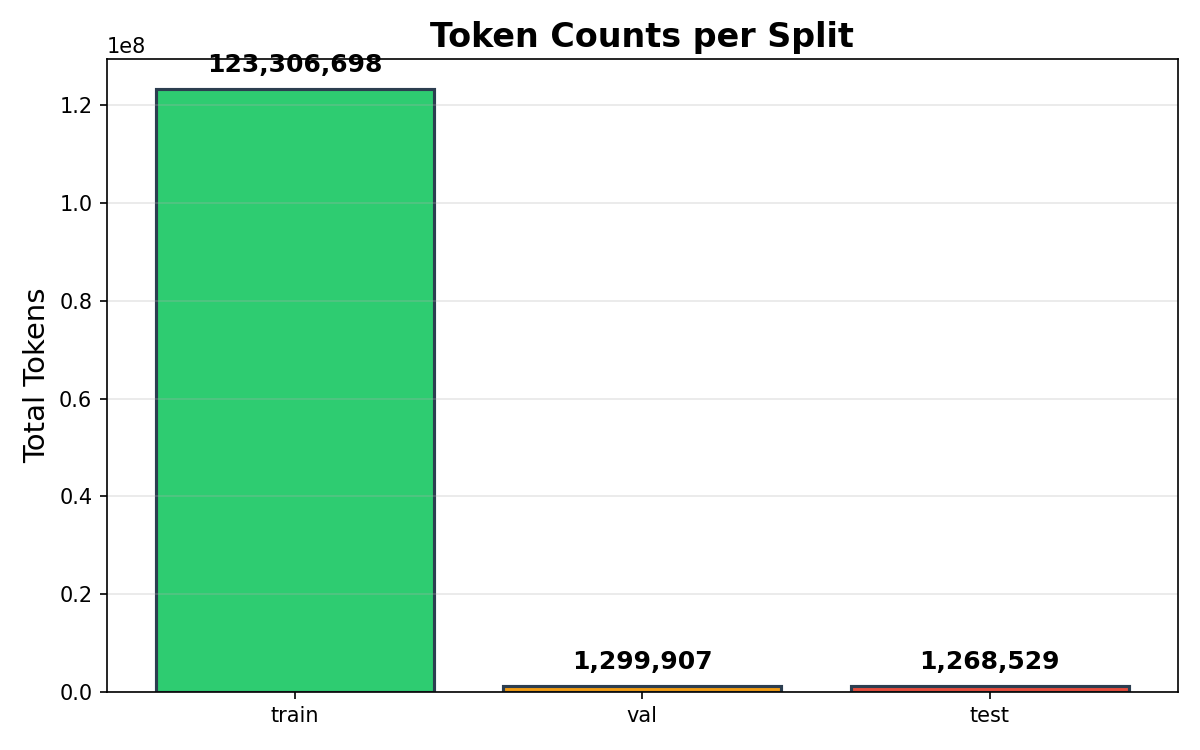


token_length_cdf.png


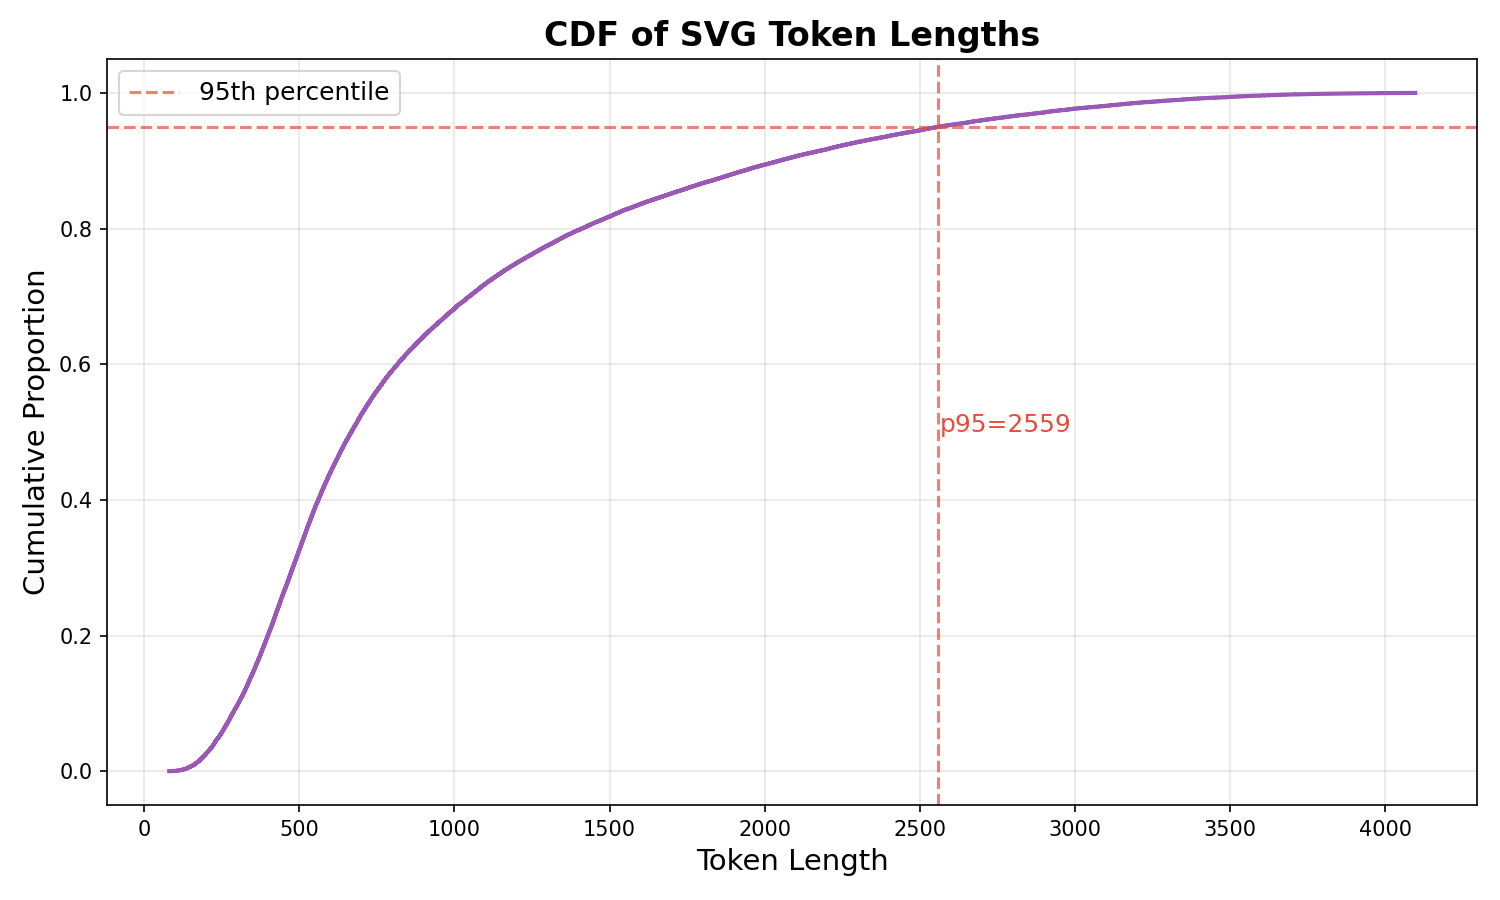


token_length_distribution.png


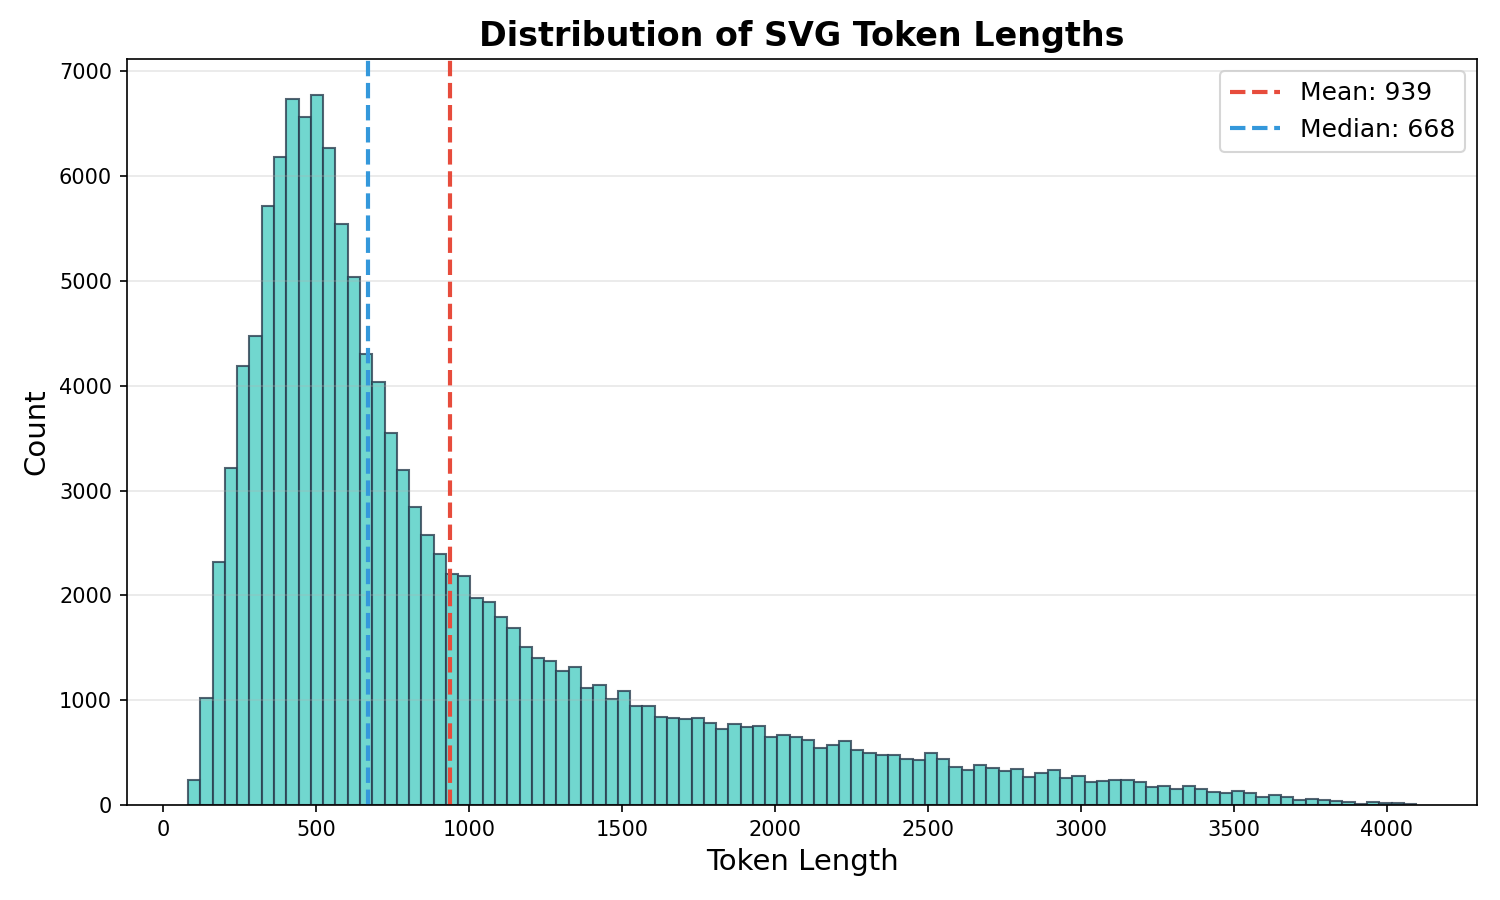


lr_sweep_comparison.png


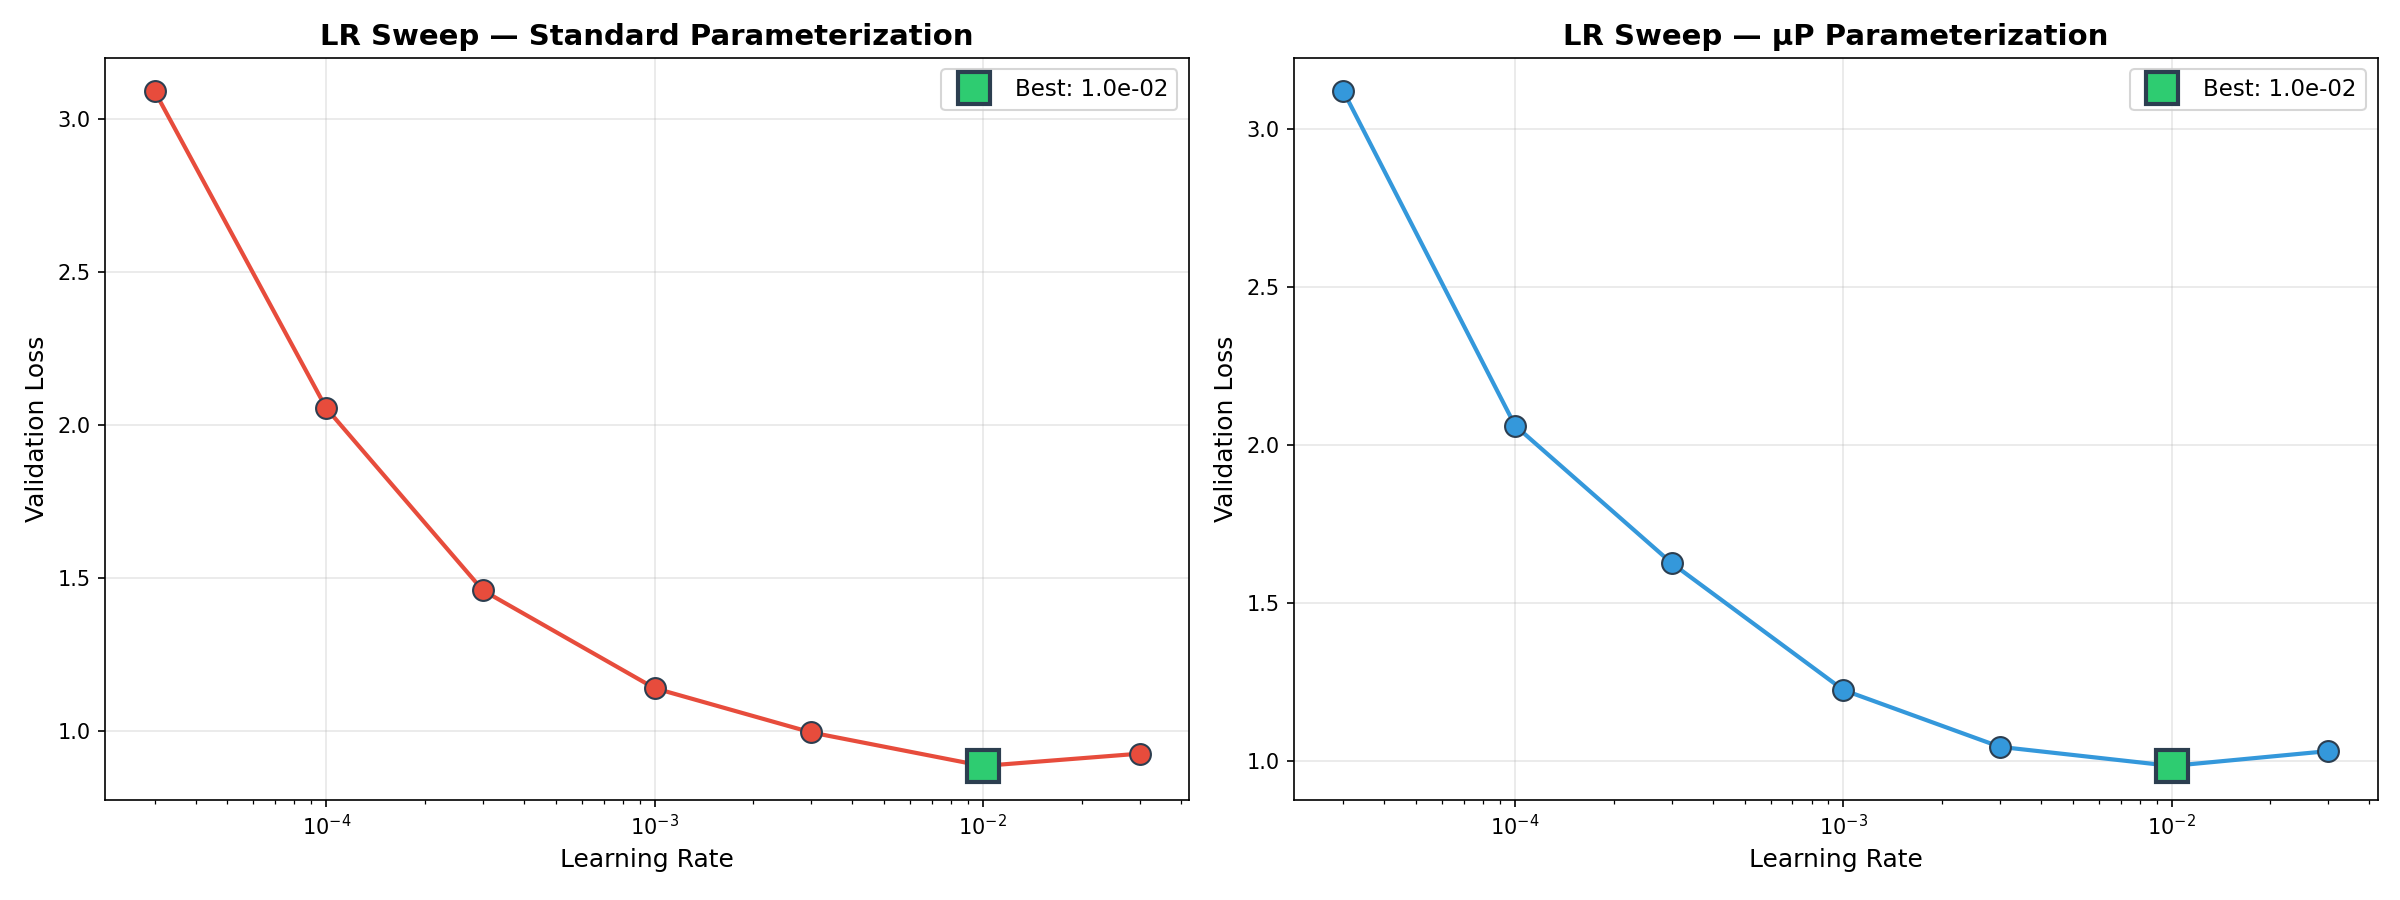


scaling_extrapolation.png


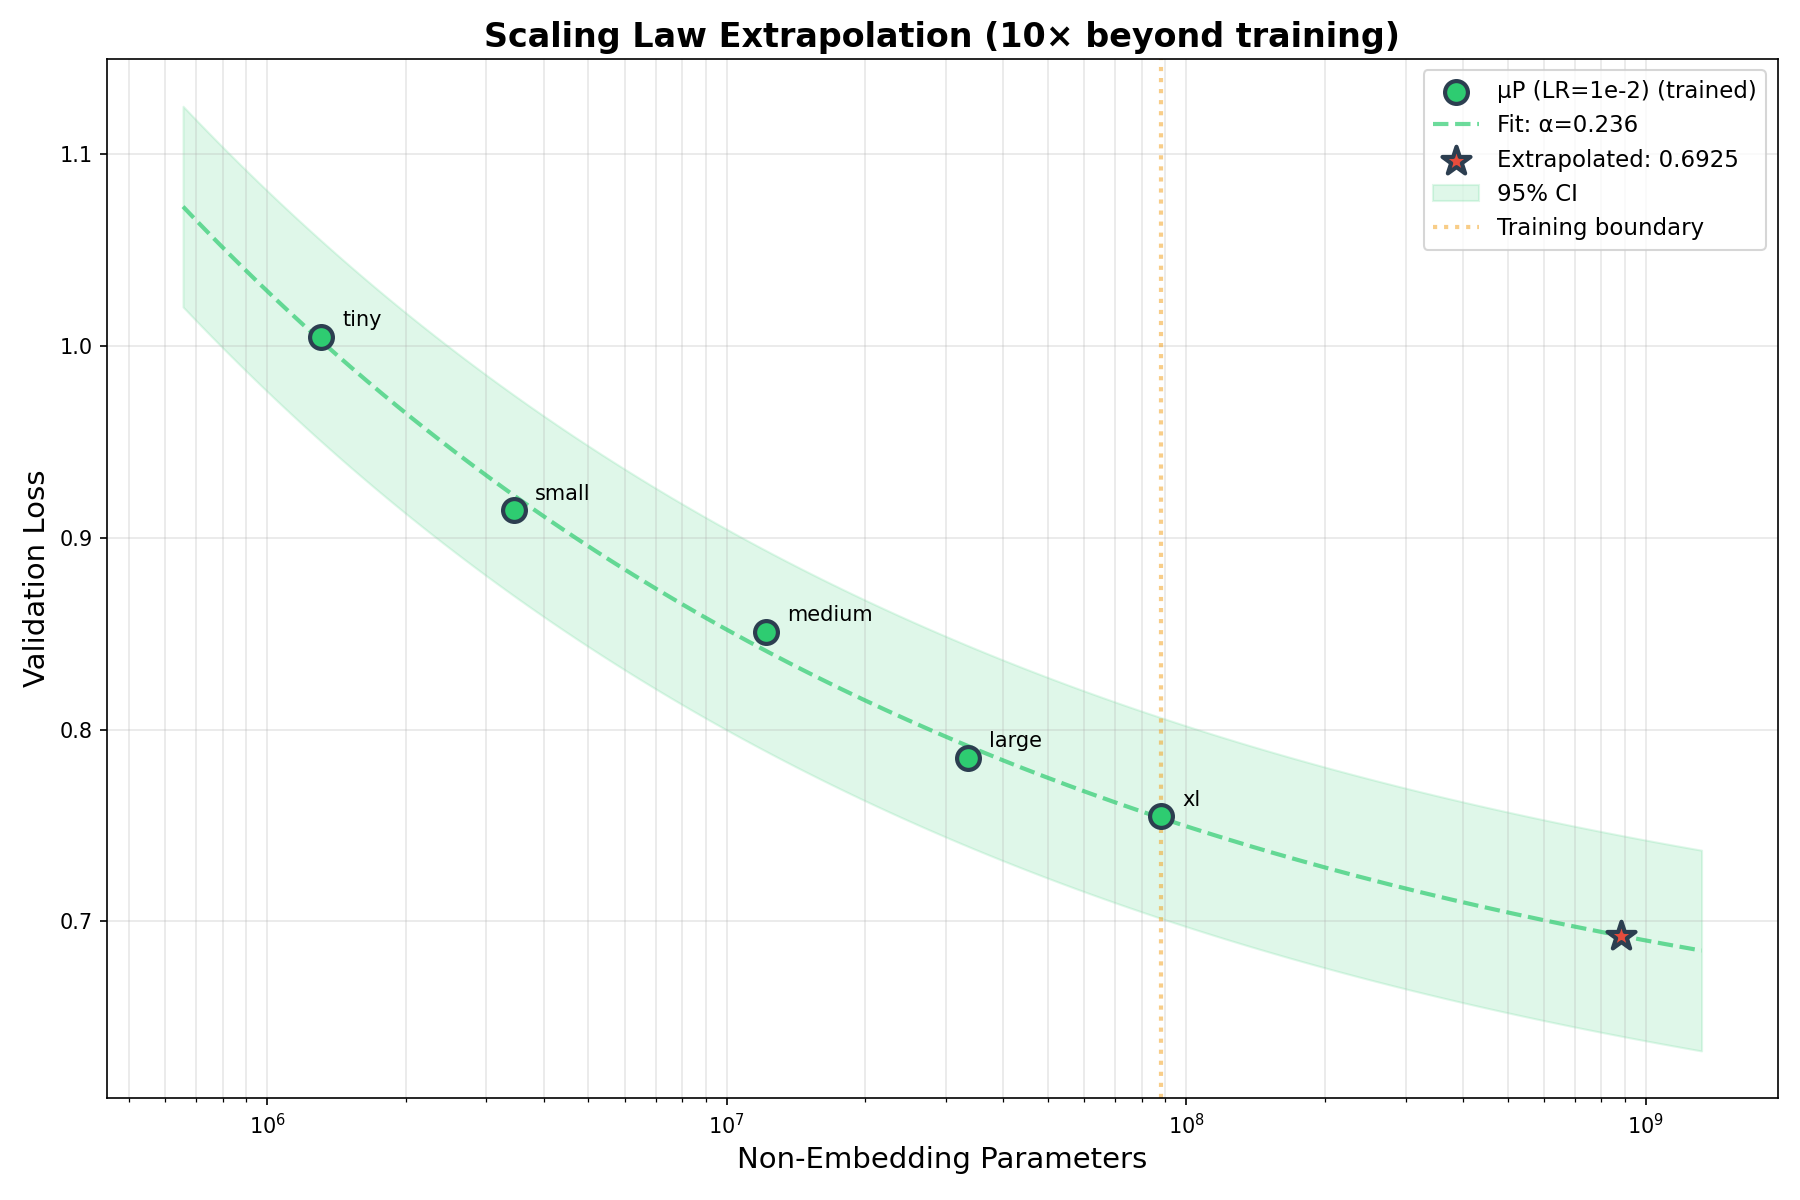


sp_scaling_curve.png


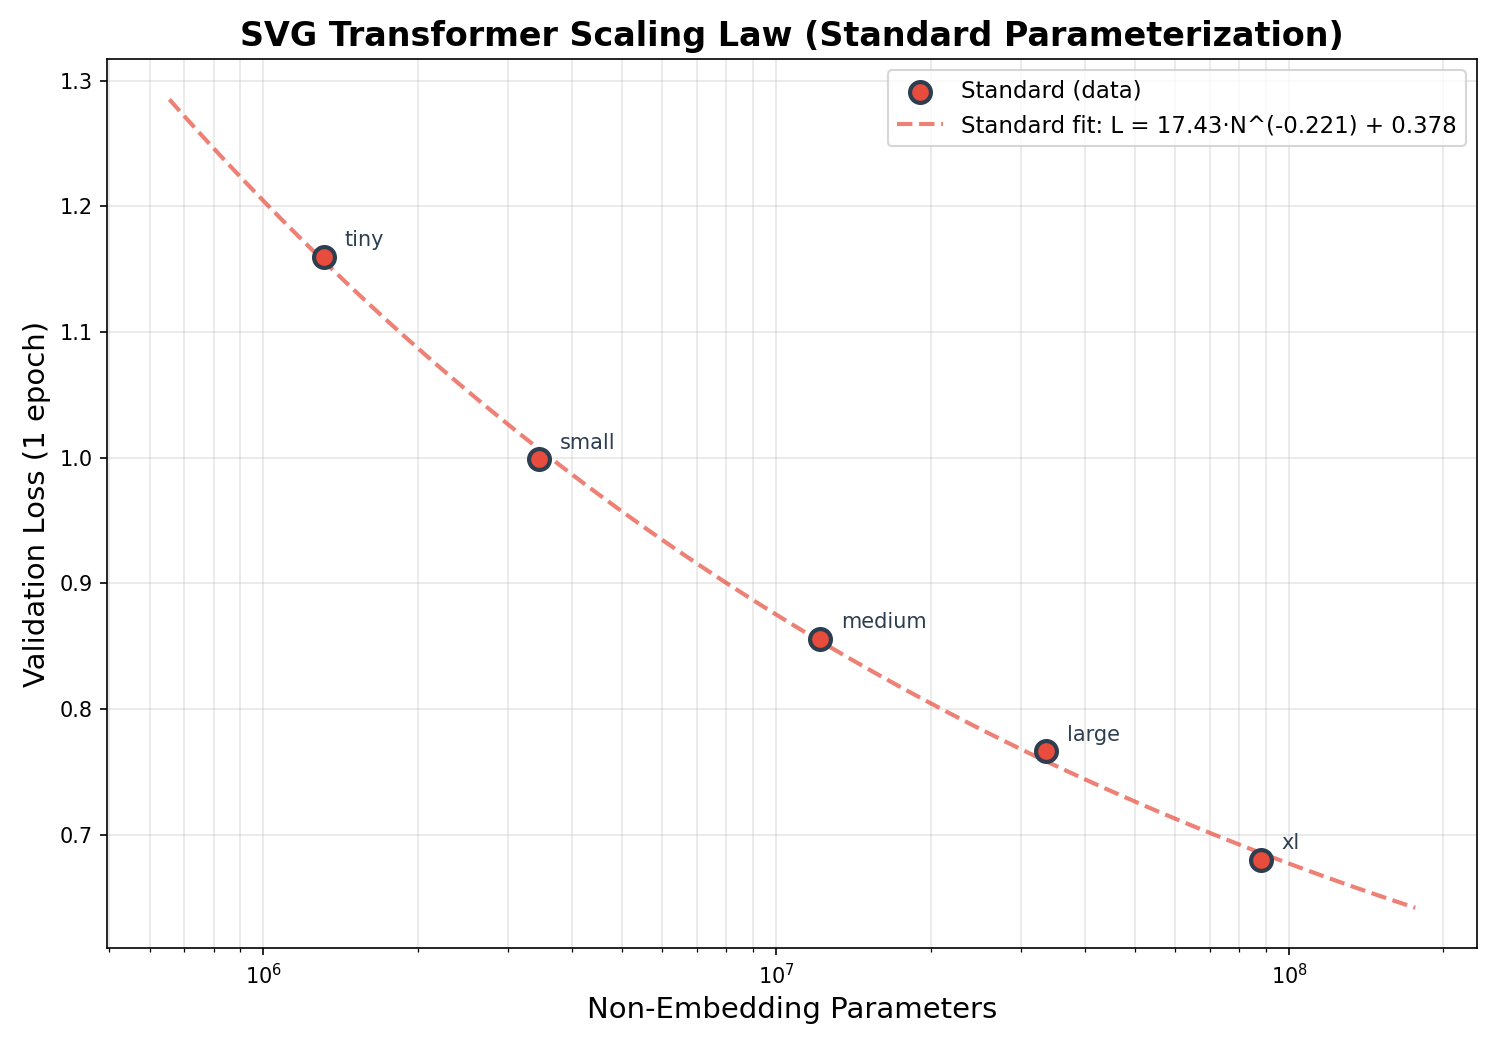


sp_training_curves.png


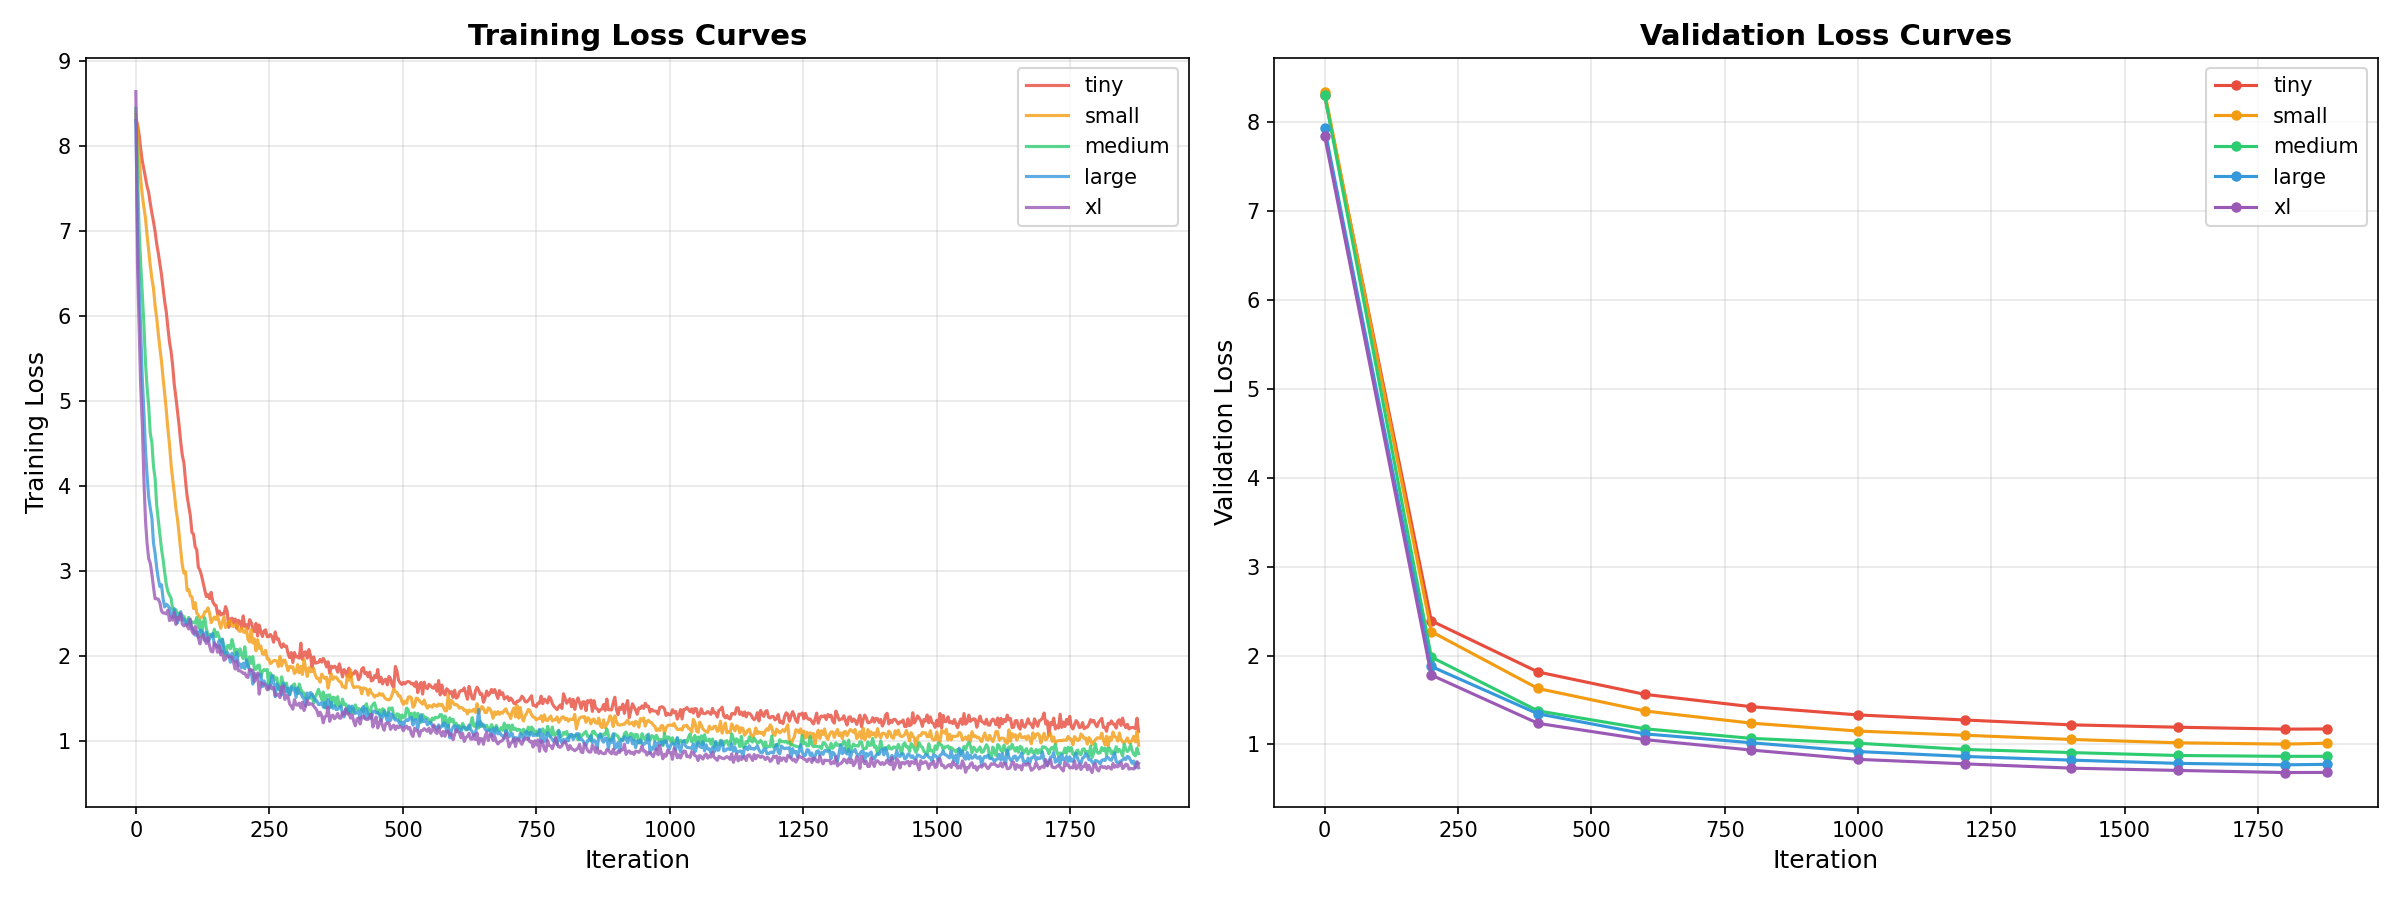


sp_vs_mup_scaling_lr1e-2.png


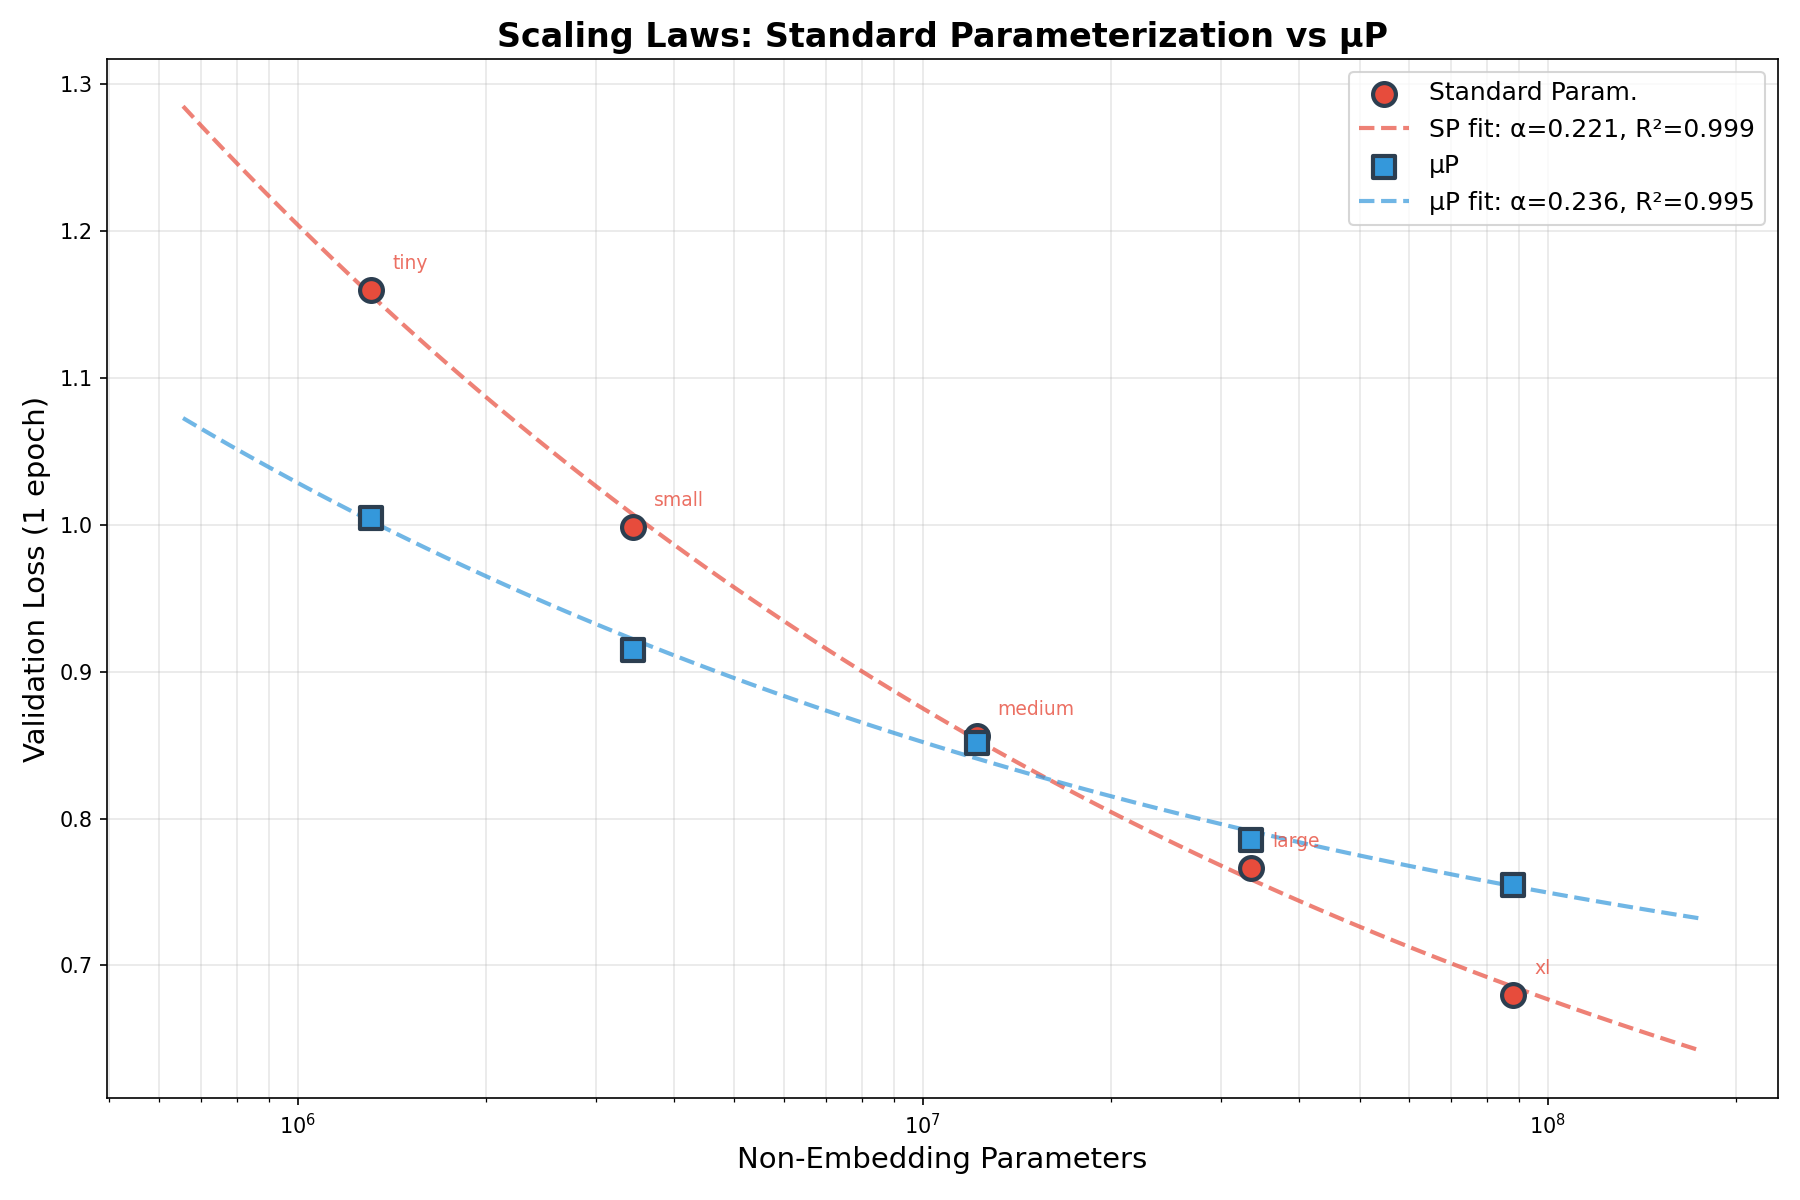


sp_vs_mup_scaling_lr3e-3.png


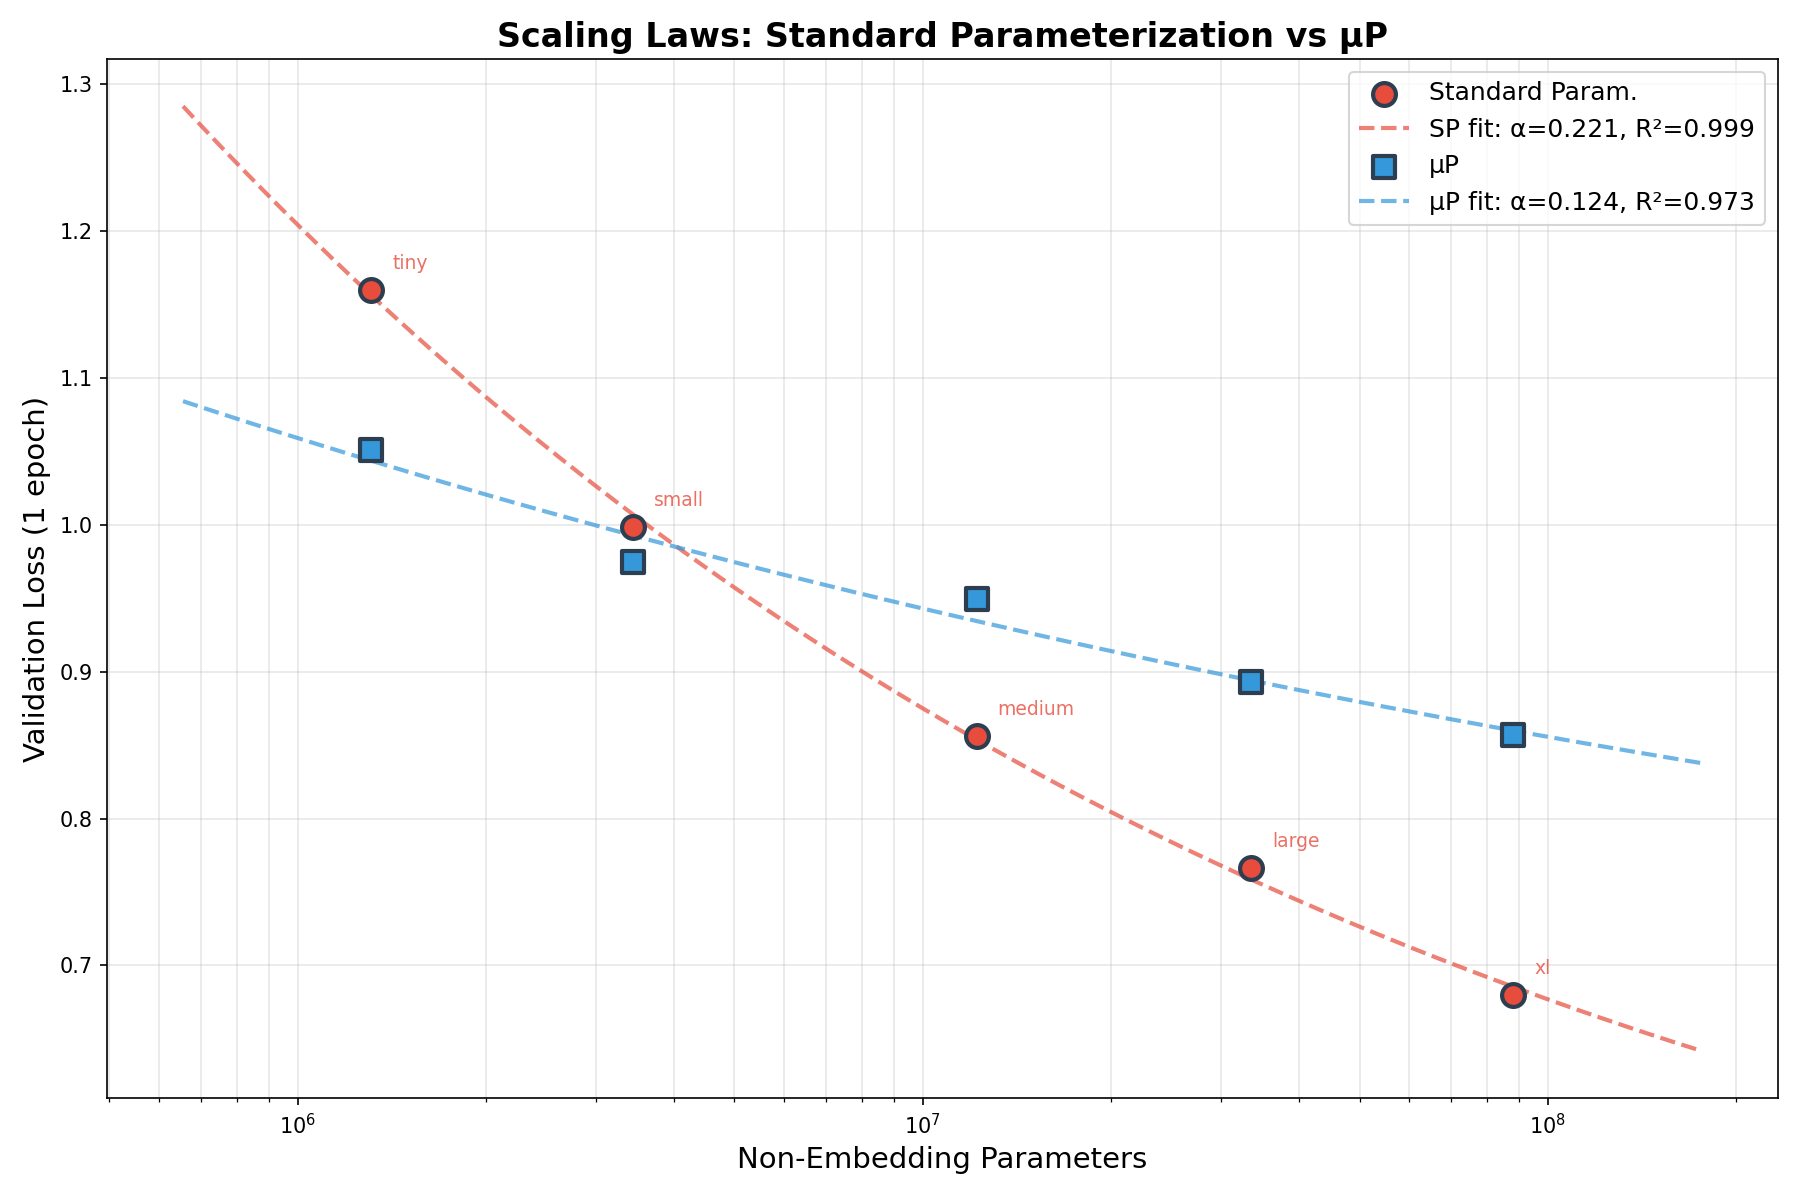


prefix_comparison.png


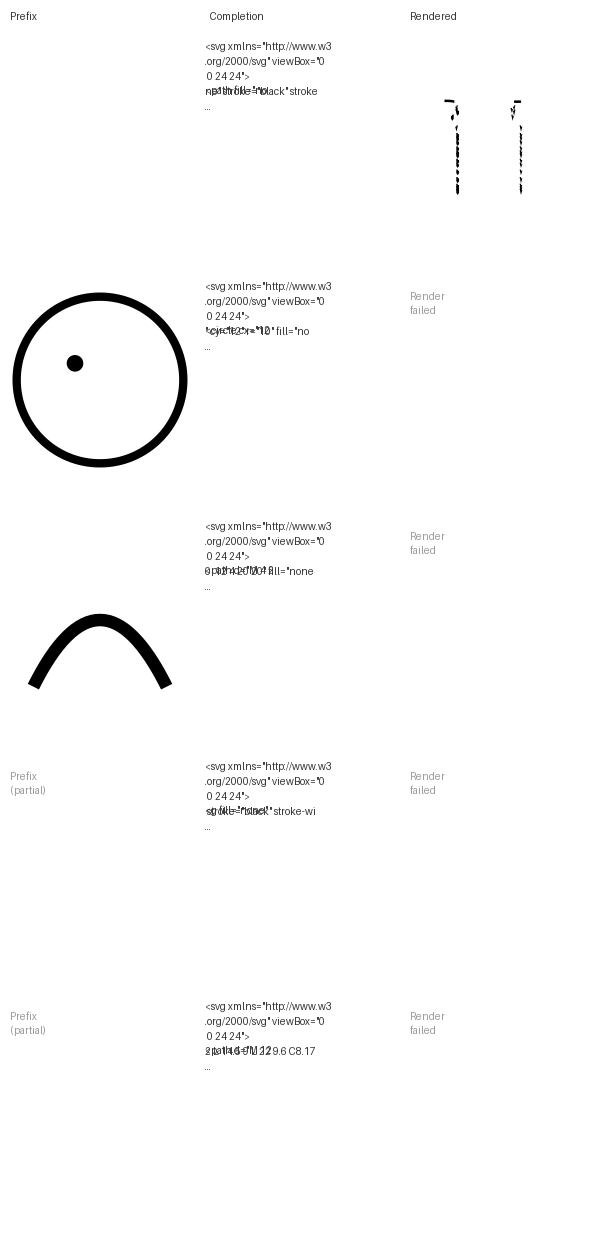


temp_0.5_grid.png


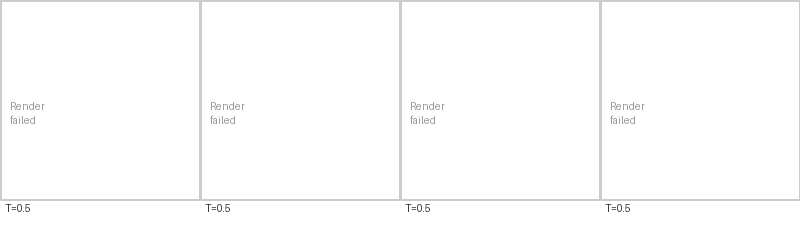


temp_0.8_grid.png


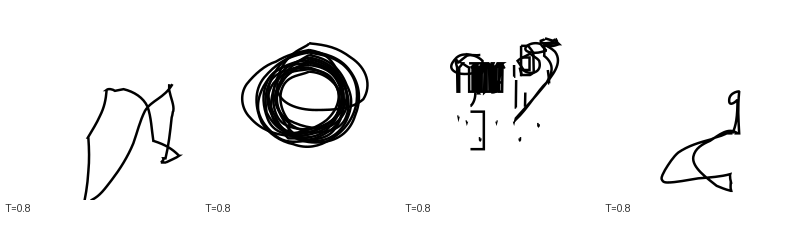


temp_1.0_grid.png


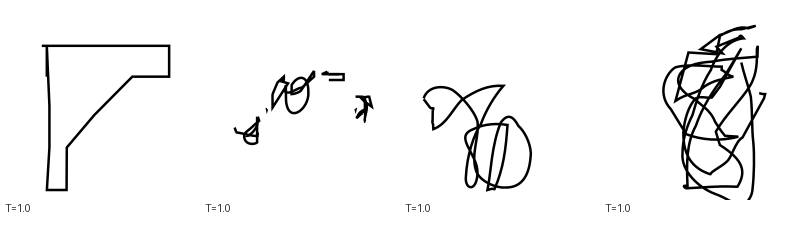


unconditional_grid.png


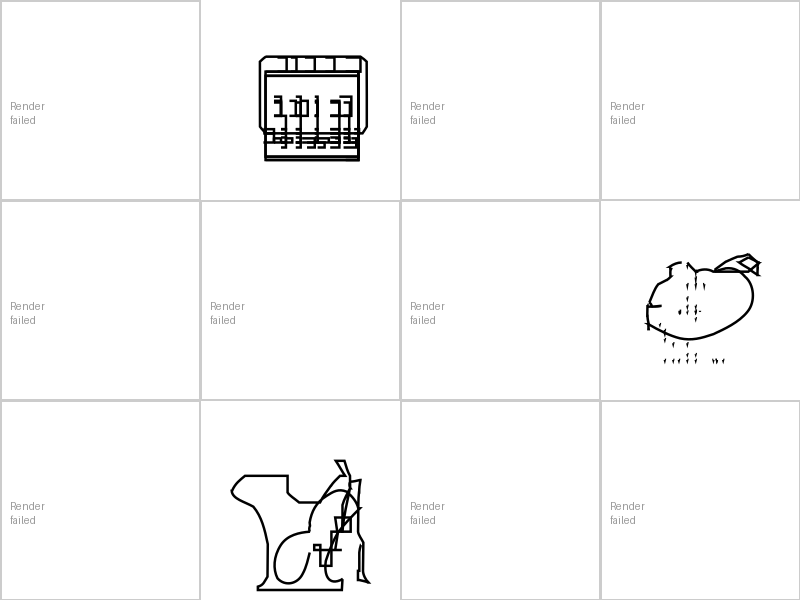

In [7]:
from IPython.display import Image, display

# Collect all generated figures
figure_dirs = [
    os.path.join(RESULTS_DIR, "data_stats"),
    ANALYSIS_DIR,
    os.path.join(RESULTS_DIR, "generation"),
    os.path.join(RESULTS_DIR, "evaluation"),
]

all_figures = []
for d in figure_dirs:
    if os.path.exists(d):
        for f in sorted(os.listdir(d)):
            if f.endswith(".png"):
                all_figures.append(os.path.join(d, f))

print(f"Found {len(all_figures)} figures for the report:\n")
for fig_path in all_figures:
    name = os.path.basename(fig_path)
    print(f"{name}")
    display(Image(fig_path, width=600))
    print()

## 5.4 Key Findings Summary

In [5]:
# Load all results for summary
print("=" * 70)
print("KEY FINDINGS SUMMARY")
print("=" * 70)

# 1. Scaling exponents
fit_path = os.path.join(ANALYSIS_DIR, "sp_power_law_fit.json")
if os.path.exists(fit_path):
    with open(fit_path) as f:
        fit = json.load(f)
    print(f"\n1. SCALING EXPONENT (Standard Parameterization):")
    print(f"   α = {fit['alpha']:.4f} (R² = {fit['r_squared']:.4f})")
    print(f"   L = {fit['a']:.4f} · N^(-{fit['alpha']:.4f}) + {fit['c']:.4f}")
    print(f"   (Kaplan et al. found α ≈ 0.076 for natural language)")

# 2. SP vs µP comparison
comp_path = os.path.join(ANALYSIS_DIR, "sp_vs_mup_comparison.json")
if os.path.exists(comp_path):
    with open(comp_path) as f:
        comp = json.load(f)
    print(f"\n2. µP vs STANDARD COMPARISON:")
    if comp["sp"]["alpha"] and comp["mup"]["alpha"]:
        print(f"   SP α = {comp['sp']['alpha']:.4f}")
        print(f"   µP α = {comp['mup']['alpha']:.4f}")
        improvement = (comp["mup"]["alpha"] / comp["sp"]["alpha"] - 1) * 100
        print(f"   µP scaling exponent is {improvement:+.1f}% vs SP")

# 3. Extrapolation
ext_path = os.path.join(ANALYSIS_DIR, "extrapolation_results.json")
if os.path.exists(ext_path):
    with open(ext_path) as f:
        ext = json.load(f)
    print(f"\n3. EXTRAPOLATION (10× largest model):")
    print(f"   Target: {ext['extrapolation']['target_params']:,} params")
    print(f"   Predicted loss: {ext['extrapolation']['predicted_loss']:.4f}")
    print(f"   95% CI: [{ext['extrapolation']['ci_95_low']:.4f}, "
          f"{ext['extrapolation']['ci_95_high']:.4f}]")

# 4. Evaluation metrics
eval_path = os.path.join(RESULTS_DIR, "evaluation", "full_evaluation.json")
if os.path.exists(eval_path):
    with open(eval_path) as f:
        ev = json.load(f)
    print(f"\n4. GENERATION QUALITY:")
    print(f"   Test perplexity: {ev['test_perplexity']:.2f}")
    print(f"   XML validity: {ev['validity']['xml_valid_rate']:.1%}")
    print(f"   SVG render rate: {ev['render_rate']:.1%}")
    print(f"   Structural validity: {ev['validity']['structurally_valid_rate']:.1%}")

KEY FINDINGS SUMMARY

1. SCALING EXPONENT (Standard Parameterization):
   α = 0.2206 (R² = 0.9988)
   L = 17.4311 · N^(-0.2206) + 0.3775
   (Kaplan et al. found α ≈ 0.076 for natural language)

2. µP vs STANDARD COMPARISON:
   SP α = 0.2206
   µP α = 0.2360
   µP scaling exponent is +6.9% vs SP

3. EXTRAPOLATION (10× largest model):
   Target: 880,995,840 params
   Predicted loss: 0.6925
   95% CI: [0.6402, 0.7449]

4. GENERATION QUALITY:
   Test perplexity: 2.03
   XML validity: 23.5%
   SVG render rate: 23.5%
   Structural validity: 23.5%


## 5.5 Design Decisions Documentation


DESIGN DECISIONS


1. TOKENIZATION STRATEGY:
   - BPE with 4096 vocabulary
   - Chosen because SVG has limited tag vocabulary (~30 tags)
     but diverse numeric values. 4K captures common coordinate
     patterns without over-fragmenting numbers.
   - ByteLevel pre-tokenizer preserves SVG structure

2. ARCHITECTURE CHOICES:
   - Pre-LayerNorm (more stable for scaling experiments)
   - GELU activation (standard for GPT-style models)
   - Flash attention (when available) for efficiency
   - No weight tying (cleaner scaling analysis)
   - 1024 context window (covers 95%+ of SVG sequences)

3. TRAINING DECISIONS:
   - AdamW optimizer (β1=0.9, β2=0.95)
   - Cosine LR schedule with linear warmup (200 steps)
   - FP16 mixed precision (required for T4 GPU memory)
   - No dropout during scaling experiments (cleaner comparison)
   - Gradient accumulation to maintain 64K tokens/step

4. µP IMPLEMENTATION:
   - Attention scaling: 1/d instead of 1/√d
   - MuReadout for output projection
   - MuAdamW optimizer with per-layer LR multipliers
   - Base shapes from Tiny model

5. SVG-SPECIFIC CONSIDERATIONS:
   - Coordinate normalization to 1 decimal (reduces vocab pressure)
   - Removal of metadata/comments (noise reduction)
   - XML validation ensures data quality
   - Both quantitative (perplexity, validity) and qualitative
     (visual inspection) evaluation
